##  Simulating at constant *temperature* rather than constant energy
### Michael Shirts, CU Boulder

Up to now, we have been integrating Newton's equations of motion, which conserve energy.  But aren't we trying to generate samples consistent with the Boltzmann distribution, $P(x) = Q^{-1} \exp(-\frac{U(x)}{k_B T})$? That definitely isn't _constant_ energy; clearly low energy states are more probable than high energy states.

In the jargon of statistical mechanics, when integrating Newton's equations of motion, we are generating samples in the NVE ensemble, meaning a system that has constant number of particles ($N$), constant volume ($V$), and constant energy ($E$).  What we want is samples from the NVT ensemble, which has constant number of particles, constant volume, and constant temperature. 

What *is* temperature? There are some specific thermodynamic and statistical mechanic definitions, but we'll keep it at a high level here. One way to simplest way to think about it is that it's a set target for the average kinetic energy of the system. 

Temperature really is just a measure of energy, but in units that are more convenient to deal with on a day-to-day basis.   We can see this in the Boltzmann distribution term $\exp(-\frac{U}{k_B T})$.  We know that you can't put anything with unit into an exponential ($e^{kilograms}$ is meaningless), so $k_B T$ is just an energy as well, and $k_B$ converts between temperature (in an absolute unit scale like Kelvin) and energy units. But we could just say things like "Oh, it's hot today - it's 2.56 kJ/mol outside!" and it would have the same scientific meaning as if we stated it in Celsius or Kelvin.

A more abstract way that's a bit more precise is that the average kinetic energy of an infinite reservoir that our system is in equilibrium with, upon exchange of heat with that system (and not particles or volume). If that reservior is infinite, then the average kinetic energy is a constant. If our system and the infinite reservoir are in thermal equilbrium, then the average kinetic energy of our reservior is the average kinetic energy of our system. You can also show that at equilibrium then $T=\frac{dU}{dS}$ at constant $N$ and $V$, where $U$ is the energy and $S$ is the entropy, but we haven't talked about entropy yet, so that's getting ahead of ourselves.

Let's code this up.  First, we import some libraries:

In [233]:
import numpy as np
import matplotlib.pyplot as plt

We'll keep using a single particle in a well.  But we want to use a potential that has two wells, so that there are two places where it could get trapped.

In [234]:
# Double well potential
def double_potential(x):
    pot = x**4 - 8*x**3 + 15*x**2
    return pot

def double_force(x):
    f = -(4*x**3 - 24*x**2 + 30*x)
    return f

FYI, for this function, the minumum is at $x=4.2247$, where $U(x) = -16.946938$, so we save that position for reference later

In [235]:
fmin = 4.2247

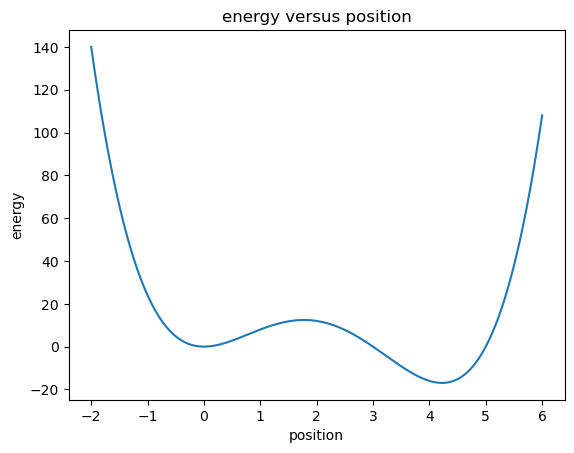

In [236]:
xlist = np.linspace(-2,6,1000)
plt.plot(xlist,potential(xlist))
plt.title('energy versus position')
plt.ylabel('energy')
plt.xlabel('position')
plt.show()

We want the system to reach thermal equilibrium at a given temperature $T$, which means that the kinetic energy will be at the Maxwell-Boltzmann distribution.

First, we define a function generating a velocity from the Maxwell-Boltzmann distribution (in 1D), which is:

$$ \sqrt{\frac{k_B T}{m}} N(0,1)$$

Where N(0,1) is a random normal (Gaussian) variable, $k_B$ is the Boltzmann constant, $T$ is the temperature, and $m$ is the mass of the particle.  A system of particles bouncing around at equilibrium will have this probability distribution of kinetic energies to be consistent with the Boltzmann distribution. 

In [237]:
kb = 8.314463 #  k in J/(K*mol)
def mb_dist(m,T,size=1):
    """
    take in a mass and a temperature, and return "size" samples from the 
    Maxwell-Boltzmann distribution with that T and m.
    """
    return np.sqrt((kb*T)/m)*np.random.normal(size=size)

What do we mean by preserving the Maxwell-Boltzmann distribution?  The Maxwell-Boltzmann distribution for a single particle is the Boltzmann distribution for the kinetic energy, i.e., $p(v) \propto \exp(-U_{kin}/k_BT)$. For 1 particle in 1D, this is $p(v) \propto \exp(-\frac{mv^2}{2k_BT})$, or if we normalize it, by integrating it from $x=-\infty$ to $\infty$, we have $p(v) = \sqrt{\frac{m}{2\pi k_BT}} \exp(-\frac{mv^2}{2k_BT})$. 

We can check that these random velocities indeed give us this correct distribution.

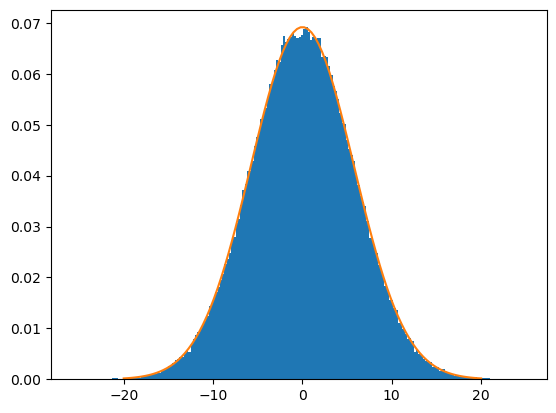

In [238]:
T = 4
m = 1
# generate a lot of samples from this distribution
velocities = mb_dist(m=m,T=T,size=200000)

# plot the histogram
plt.hist(velocities,density=True,bins=200)

# compare the histogram to the analytical distribution
v = np.linspace(-20,20,100)
plt.plot(v,np.sqrt(m/(2*np.pi*kb*T))*np.exp(-(m*v**2)/(2*kb*T)))
plt.show()

Next, we will use the simple procedure of randomize the velocities every $N$ steps from the Maxwell-Boltzmann distribution.  This is known as the _Andersen thermostat_.

In [239]:
def velocity_verlet(x,v,force,m=1,dt=1):
    # just the same as in the previous notebook
    
    '''
    a function that executes one step of numerical integration
    inputs:
        x (current position)
        v (current velocity)
        f (a function that computes the force)
        m = mass of particle
        dt = time interval        
    '''
    
    v_h = v + 0.5*dt*(force(x)/m)  # half a step in x
    x = x + v_h*dt  # half a step in v
    v = v_h + 0.5*dt*(force(x)/m)

    return x,v

In [240]:
def do_some_andersen(nsteps=100, m=1, dt=0.1, init_x=0, init_v=6, T=50, tau=100, 
                     potential=double_potential, force=double_force):
    '''
    inputs: 
        nsteps = number of steps
        m = mass of particle
        dt = timestep length
        init_x, init_v = initial position and velocity
        T = temperature 
        tau = period (in number of steps) to randomize velocity
    output:
        results dictionary
    '''

    # we need to declare arrays to store data
    xs = np.zeros(nsteps)
    vs = np.zeros(nsteps)
    PEs = np.zeros(nsteps)
    KEs = np.zeros(nsteps)

    # initialize the x and v
    x = init_x
    v = init_v

    xs[0] = x
    vs[0] = v

    PEs[0] = potential(x)
    KEs[0] = 0.5*m*(v)**2

    for i in range(1,nsteps):
        xnew,vnew = velocity_verlet(x,v,m=m,dt=dt,force=force)
        if i%tau==0:
            # randomize the particle velocity. This is the key point that gives constant T.
            # mb_dist returns an array with 1 entry, so we need to turn it into a scalar.
            vnew = mb_dist(m,T)[0]
        x = xnew
        v = vnew
        xs[i] = x
        vs[i] = v
        KEs[i] = 0.5*m*(vs[i])**2
        PEs[i] = potential(x)

    results = dict()
    results['x'] = xs
    results['v'] = vs
    results['KE'] = KEs
    results['PE'] = PEs
    results['Total_E'] = KEs + PEs
    
    return results

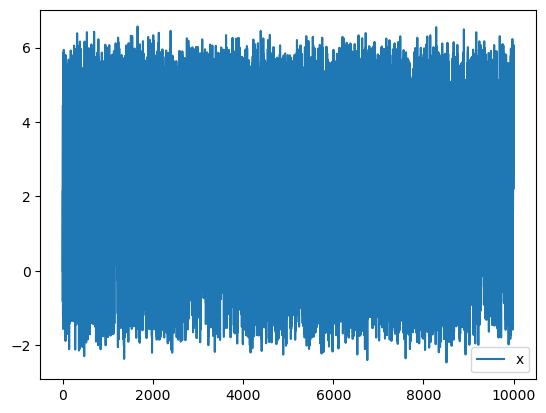

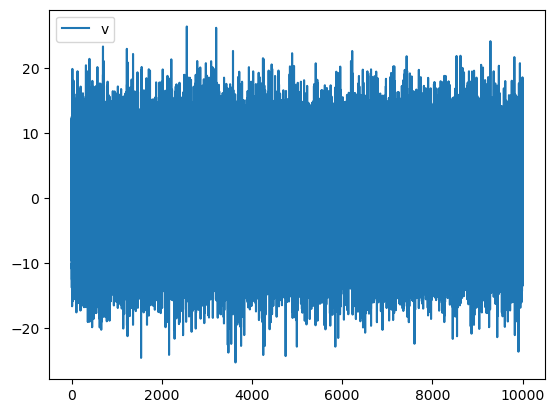

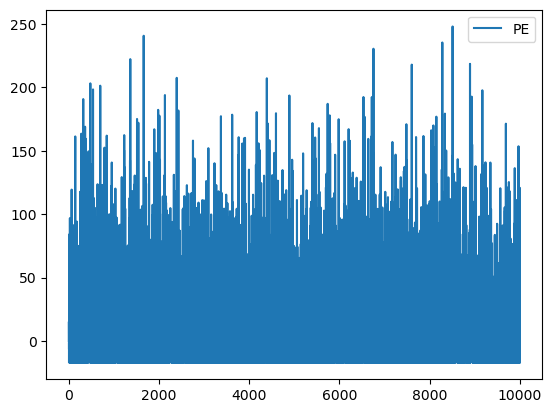

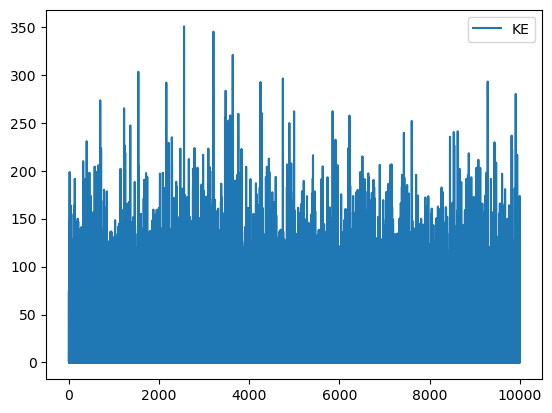

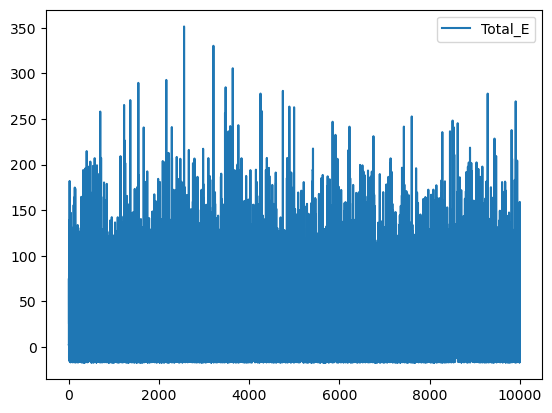

In [245]:
nsteps = 500000
dt = 0.02
T = 4

results = do_some_andersen(nsteps=nsteps, init_x = 0, init_v=2, dt=dt, T=T,tau=5)

ts = dt*np.arange(nsteps)
properties = ('x','v','PE','KE','Total_E')
for property in properties:
    plt.plot(ts,results[property],label=property)
    plt.legend()
    plt.show()

So we can see that we have wells at zero and 4, it's transiting back and forth between those well relatively quickly. At least at this temperature!

**Questions**:  

1. Why might we not want to randomize every step?
2. What happens if you run with very low $\tau$ (i.e. no randomizations within the time period)
3. What happens if you run at higher $\tau$ (randomizing every 100 steps)? 
4. What happens when you run at lower and higher temperatures?

What you should see at lower temperature is that it transits between the wells much more slowly, and if the temperature is low enough, remains in just one well the entire time (whichever one it starts from).  

</br>
</br>
</br>
</br>
</br>
</br>

### Testing correctness

**Question**: How can we test if we are doing the right thing?  

This is perhaps the biggest question we can ask for for simulations, or any modeling?  How do I know that I'm actually modeling the thing I want to be modeling


One thing we know is that if it is thermal equilibrium, then $\langle KE \rangle = \frac{n}{2} k_B T$, where $n$ is the number of degrees of freedom (DOF).  How many degrees of freedom are there in this case? How can we check the temperature? 

**Answer**: One degree of freedom, meaning that what we _should_ have is $T = 
    \frac{2}{k} \langle KE \rangle$.

In [246]:
print("Ave KE = ", np.mean(results['KE']))
print("Estimated T=", (2/k)*np.mean(results['KE']))

Ave KE =  16.72711062613866
Estimated T= 4.023617791344711


Indeed we do!  There will always be a little noise, but we'll talk later about how whether this is the amount of noise we expect. 

More generally, our velocities should match the Maxwell-Boltzmann distribution, defined last time for 1D, and we can check that as well:

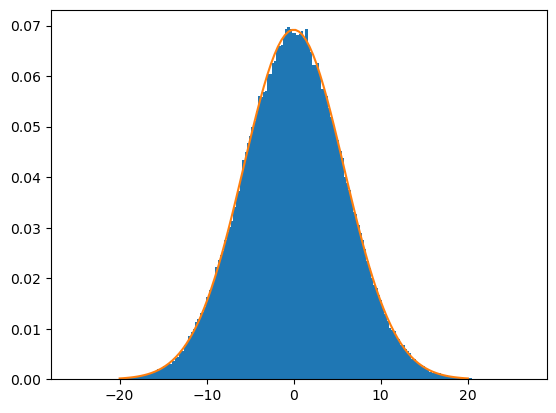

In [249]:
# generate a lot of samples from this distribution
# plot the histogram
plt.hist(results['v'],density=True,bins=200)
# compare to the distribution
v = np.linspace(-20,20,100)
plt.plot(v,np.sqrt(m/(2*np.pi*kb*T))*np.exp(-(m*v**2)/(2*kb*T)))
plt.show()

Finally, we can also compute the free energy as a function of $x$, which because the system is just one-dimensional, will also be the potential energy.  We can do this by computing $P(x)$, then finding $G(x) = -k_B T \ln P(x) = U(x)$, the potential we started out with.  Note that one can only find the free energy surface up to a constant, so we have subtract to find the minimum.  Also, note that this trick only works well in 1D, because it's really hard to collect a histogram in many dimensons.  

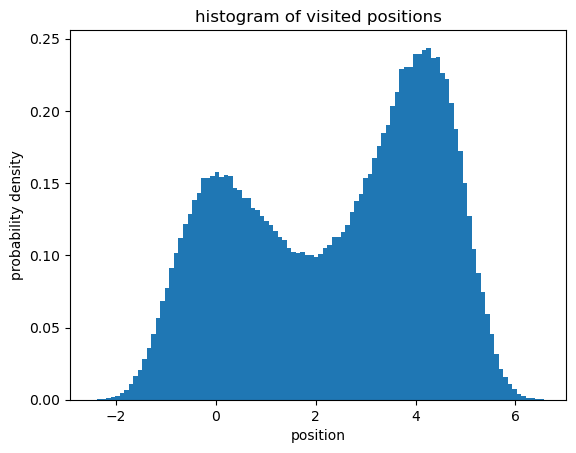

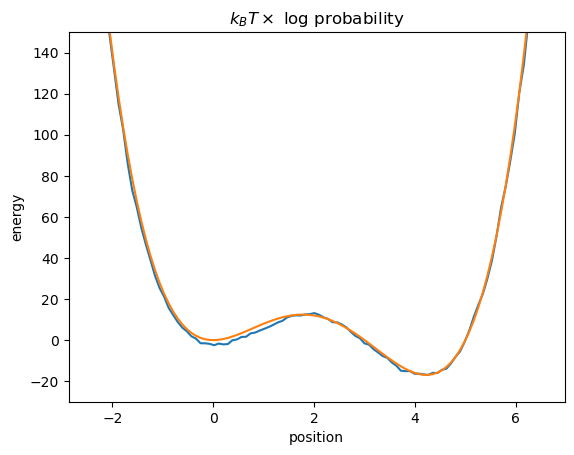

In [250]:
res = plt.hist(results['x'],bins=100,density=True)
plt.title('histogram of visited positions')
plt.ylabel('probability density')
plt.xlabel('position')
plt.show()

bin_locs = 0.5*(res[1][1:]+res[1][:-1])
Effective_U = -k*T*np.log(res[0])

# shift it so it as the minimum has the right value 
Shift_U = Effective_U - (np.min(Effective_U)-potential(fmin))
plt.plot(bin_locs,Shift_U)
plt.plot(bin_locs,potential(bin_locs))
plt.title(r'$k_BT \times$ log probability')
plt.ylabel('energy')
plt.xlabel('position')
plt.ylim([-30,150])
plt.show()

Up to some small amout of noise, it's the same function! 

This is important - we have now generated samples from the probability function $p(x) = Q^{-1}\exp(-\frac{U(x)}{k_B T})$.  But we did not need to come up with some specialized function to do this; this process will work for essentially _any_ energy function $U(x)$.

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

## Temperature versus average kinetic energy

One thing that you can often see in molecular simulation outputis the conversion of the kinetic energy to something with the units of temperature at each point.  For example:

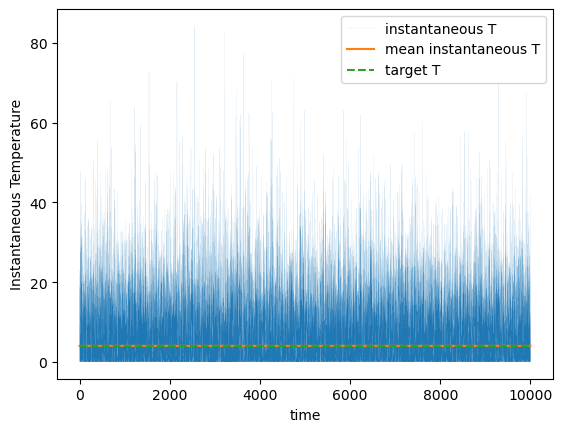

In [251]:
instantaneous_temperature = (2/kb)*results['KE']
plt.plot(ts,instantaneous_temperature,lw=0.04,label='instantaneous T')
plt.plot(ts,np.ones(len(ts))*np.mean(instantaneous_temperature),label='mean instantaneous T')
plt.plot(ts,np.ones(len(ts))*T,ls='--',label='target T')
plt.ylabel('Instantaneous Temperature')
plt.xlabel('time')
plt.legend()
plt.show()

The average of this quantity $\frac{2}{nk_BT}KE$, where in this case $n$, the number of degrees of freedom is 1, is indeed very nearly 2, the target temperature.  But any any given instant in time, it can be very different from 2! This fluctuating quantity is _not_ the temperature, but instead a quantity that averages out to the temperature when scaled the correct way. 

The larger the system is, the less this average fluctuates, so it gets a little more confusing for big systems, as this quantity jiggles closely around the target temperature.  But don't confuse it with the temperature!  At minimum, it should be described as the instantaneous temperature.  We are simulating in the NVT ensemble, which means _constant_ temperature.  Temperature doesn't move up and down.  Additionally if we are looking at the Boltmann distribution $p(x) = Q^{-1} \exp(-U(x)/k_B T)$, then it doesn't really make sense to have a $T$ that changes with $x$. Nope!  $T$ is a constant, a property that we constrain the system to, so that the kinetic energy averages out. 

</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>
</br>

## The Langevin Thermostat

What if instead of rerandomizing the force to a Maxwell-Boltzman distribution every few steps, we added a bit of random forces each step?  

Let's think through how we want to do this. If we add energy to a system already at our target $T$, we will have too much energy in our system. So we will need to remove that extra energy, and removing it by friction makes the most physical sense -- we can imagine that our particle is colliding with other particles in the system (even if they are kind of imaginary here -- we only have one particle we are moddeling!)  With friction, the force is proportional to the velocity, and we'll keep it simple by making it linearly proportional to velocity.  So instead of 

$$m\frac{dv}{dt} = a$$

we have:

$$m\frac{dv}{dt} = a -\gamma v + bN(0,1)$$

Where $\gamma$ is a friction constant with units $1/t$, and $b$ is a scaling term that cancels out the energy.

We can implement that within the velocity Verlet framework by rescaling the velocity at the half-step.  It requires a bit of calculus to integrate the differential equation, which we will skip since it involved integrating a random number (we are not learning stochastic differential equations) but we end up with the following equation:

$$v(t+\Delta t/2) = v(t) + \frac{1}{2m}F(x(t))\Delta t$$
$$x(t+\Delta t) = x(t) + v(t+\Delta t/2)\Delta t$$
$$v_{scaled}(t+\Delta t/2) = \exp(-\gamma\Delta t) v(t+\Delta t/2) + \sqrt{\frac{k_BT}{m}(1-\exp(-2\gamma\Delta t))}N(0,1)  \quad 
\longleftarrow\; \text{This step is new}$$ 
$$v(t+\Delta t) = v_{scaled}(t+\Delta t/2) + \frac{1}{2m}F(x(t+\Delta t))\Delta t$$

There's a couple of different ways to do it, but all converge to the same results as the time step gets small. 

One thing we will do to make it closer to the Andersen thermostat is, since $\gamma$ is in units of $1/t$, we will use instead the variable $\tau = 1/\gamma$, which has units of time.  This represents a characteristic time that we 'replace' the old energy of the system with 'new' energy from outside the system. 

So implementing this we get: 

In [217]:
def langevin(x,v,force,m=1,dt=1,tau=10,T=50):

    '''
    Inputs are the current x and v, 
    the force function, the mass, the timstep, a 
    timescale tau for adding more energy in / sucking it out 
    (can be thought of as an inverse of a friction, 
    and the temperature.

    '''
    v_h = v+0.5*dt*(force(x)/m)  # half a step in x
    x = x+0.5*v_h*dt  # half a step in v
    sig = (1-np.exp(-2*dt/tau))
    # sig = sqrt(J/kg) = m/s (units)
    a = np.exp(-dt/tau)
    b = np.sqrt(sig)
    v_h = a*v_h + b*mb_dist(m,T)[0]  # randomize v
    x = x+0.5*v_h*dt # half a step in v
    v = v_h + 0.5*dt*force(x)/m  # half a step in x
    
    return x,v

**Exploration:** 

How is simulating with different $\tau$ different the Langevin integrator compared to the Andersen thermostat?  How do the trajectories look different with large $\tau$?  How about with small $\tau$?  Remember that $\tau$ cannot be less than $\Delta t$.

In [252]:
def do_some_langevin(nsteps=100, m=1, dt=0.1, 
               init_x = 0, init_v=2,T=50,tau=50):

    xs = np.zeros(nsteps)
    vs = np.zeros(nsteps)
    PEs = np.zeros(nsteps)
    KEs = np.zeros(nsteps)

    x = init_x
    v = init_v

    xs[0] = x
    vs[0] = v
    KEs[0] = 0.5*m*v**2
    PEs[0] = potential(x)
    
    for i in range(nsteps):
        xnew,vnew = langevin(x,v,force,m=m,dt=dt,T=T,tau=tau)
        x = xnew
        v = vnew
        xs[i] = x
        vs[i] = v
        KEs[i] = 0.5*m*(vs[i])**2
        PEs[i] = potential(x)

    results = dict()
    results['x'] = xs
    results['v'] = vs
    results['KE'] = KEs
    results['PE'] = PEs
    results['Total_E'] = PEs + KEs
    
    return results

In [268]:
nsteps = 500000
dt = 0.02
T = 2

results = do_some_langevin(nsteps=nsteps, dt=dt, init_v=2, T=T, tau=5)

Now let's graph the results!

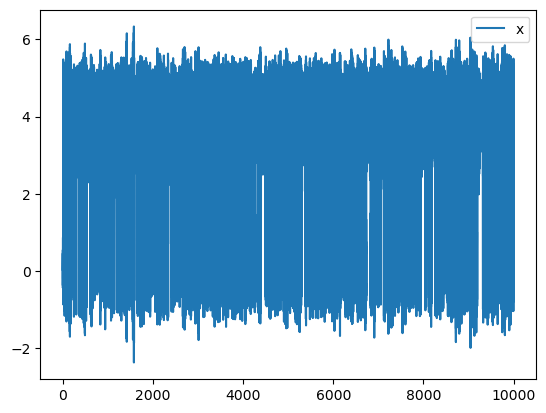

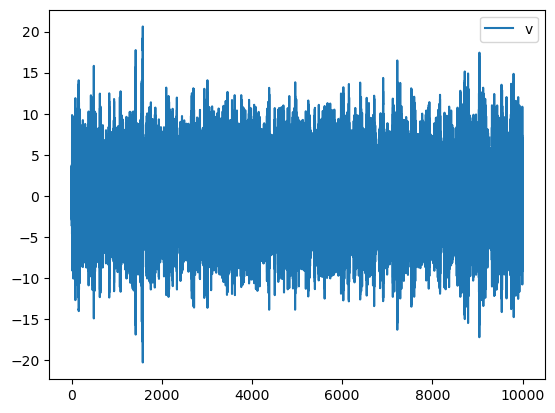

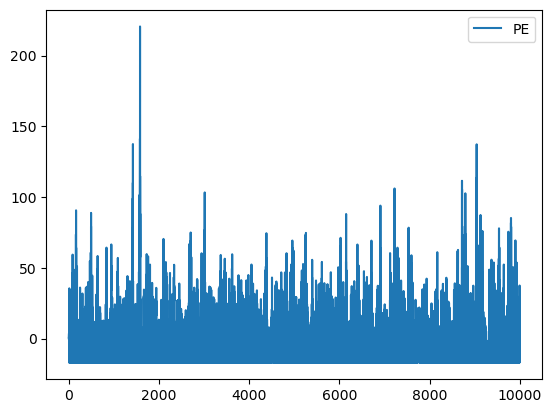

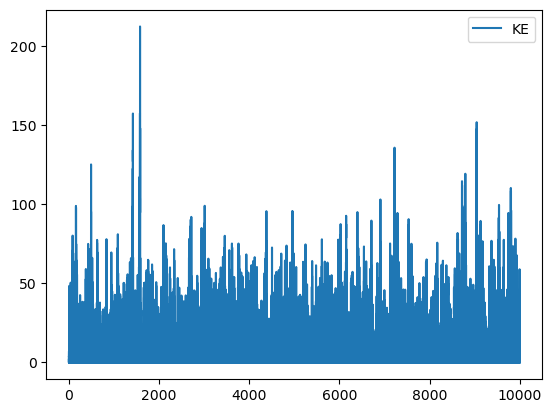

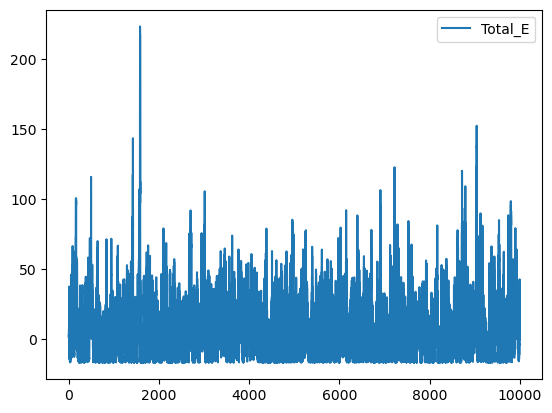

In [269]:
properties = ('x','v','PE','KE','Total_E')
for property in properties:
    ts = dt*np.arange(nsteps)
    plt.plot(ts,results[property],label=property)
    plt.legend()
    plt.show()

Now let's do our checks!

First, check that the average kinetic energy is right.

In [270]:
print("Ave KE = ", np.mean(results['KE']))
print(f"Estimated T={(2/k)*np.mean(results['KE'])} and true T is {T}")

Ave KE =  8.266029013404506
Estimated T=1.988349461271162 and true T is 2


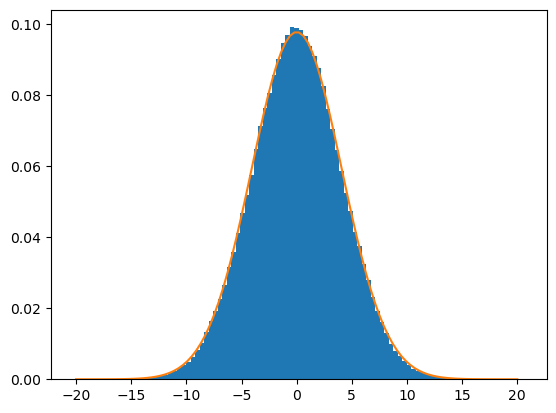

In [271]:
# generate a lot of samples from this distribution
# plot the histogram
plt.hist(results['v'],density=True,bins=100)
# compare to the distribution
v = np.linspace(-20,20,100)
plt.plot(v,np.sqrt(m/(2*np.pi*kb*T))*np.exp(-(m*v**2)/(2*kb*T)))
plt.show()

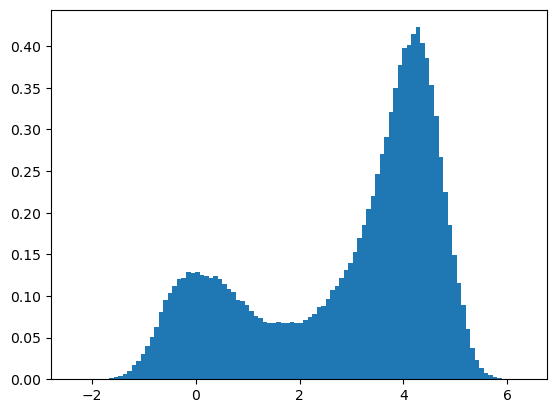

In [272]:
res = plt.hist(results['x'],density=True,bins=100)
plt.show()

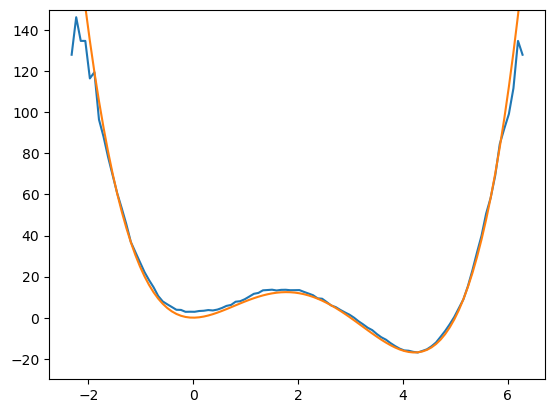

In [273]:
bin_locs = 0.5*(res[1][1:]+res[1][:-1])  # check this . . . 
Effective_U = -k*T*np.log(res[0])
# shift it so it as the minimum at the same place
Shift_U = Effective_U - (np.min(Effective_U)-potential(fmin))
plt.plot(bin_locs,Shift_U)
plt.plot(bin_locs,potential(bin_locs))
plt.ylim([-30,150])
plt.show()

You should be getting very similar results as you got with the Andersen thermostat, as long as $\tau$ is short compared to the number of steps.  If $\tau$ is too big, then the statistics will be poor, and the averages and distributions will be noisy. 


There's a few other algorithms that have been developed to control the temperature, but these two give a good sense of the processes involved.